# Sistemas de recomendación: Book-Crossing

**Objetivo.** Comparar recomendaciones basadas en popularidad, contenido y filtrado colaborativo, con énfasis en *fairness* entre grupos demográficos y de comportamiento.


## 1. Descarga del dataset

Se descargan las tres tablas del repositorio de Book-Crossing solo si todavía no existen localmente.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

base_url = 'https://raw.githubusercontent.com/ashwanidv100/Recommendation-System---Book-Crossing-Dataset/master/BX-CSV-Dump/'
files = ['BX-Book-Ratings.csv', 'BX-Books.csv', 'BX-Users.csv']

for file_name in files:
    destination = DATA_DIR / file_name
    if not destination.exists():
        print(f'Descargando {file_name}...')
        urlretrieve(base_url + file_name, destination)
    else:
        print(f'{file_name} ya existe')

BX-Book-Ratings.csv ya existe
BX-Books.csv ya existe
BX-Users.csv ya existe


In [2]:
read_options = dict(encoding='latin-1', sep=';', quotechar='"', on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv(DATA_DIR / 'BX-Book-Ratings.csv', **read_options)
books = pd.read_csv(DATA_DIR / 'BX-Books.csv', **read_options)
users = pd.read_csv(DATA_DIR / 'BX-Users.csv', **read_options)

print('ratings:', ratings.shape, '| books:', books.shape, '| users:', users.shape)
display(ratings.head(), books.head(), users.head())

ratings: (1149780, 3) | books: (271360, 8) | users: (278858, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


## 2. Preprocesamiento y exploración

### Limpieza de valores nulos

En Book-Crossing, un rating igual a `0` representa una interacción implícita y no una valoración explícita. Se conserva por separado, pero para entrenar y evaluar predicciones se usan ratings de 1 a 10. Las edades imposibles se consideran faltantes; no se imputan para evitar inventar información demográfica.

In [3]:
def missing_report(df):
    return (df.isna().mean().mul(100)
              .rename('missing_%')
              .to_frame()
              .sort_values('missing_%', ascending=False))

print('Nulos en ratings')
display(missing_report(ratings))
print('Nulos en books')
display(missing_report(books))
print('Nulos en users')
display(missing_report(users))

# Normalización y deduplicación
ratings = ratings.drop_duplicates(['User-ID', 'ISBN'], keep='last').copy()
books = books.drop_duplicates('ISBN', keep='first').copy()
users = users.drop_duplicates('User-ID', keep='first').copy()

users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
users.loc[~users['Age'].between(5, 100), 'Age'] = np.nan
users['Country'] = (users['Location'].fillna('unknown')
                     .str.rsplit(',', n=1).str[-1]
                     .str.strip().str.lower()
                     .replace('', 'unknown'))
books['Book-Title'] = books['Book-Title'].fillna('')
books['Book-Author'] = books['Book-Author'].fillna('Desconocido')

ratings_reales = ratings.loc[ratings['Book-Rating'].between(1, 10)].copy()
print(f'Ratings reales: {len(ratings_reales):,} de {len(ratings):,}')

Nulos en ratings


,missing_%
User-ID,0.0
ISBN,0.0
Book-Rating,0.0


Nulos en books


,missing_%
Image-URL-L,0.001106
Book-Author,0.000737
Publisher,0.000737
ISBN,0.000000
Year-Of-Publication,0.000000
Book-Title,0.000000
Image-URL-S,0.000000
Image-URL-M,0.000000


Nulos en users


,missing_%
Age,39.719857
User-ID,0.000000
Location,0.000000


Ratings reales: 433,671 de 1,149,780


### Histogramas

Graficamos por un lado los ratings reales (es decir de 1 a 10), y por otro la distribucion de las edades, utilizando 30 bins para ver su distribucion real y luego poder decidir como formar los grupos.

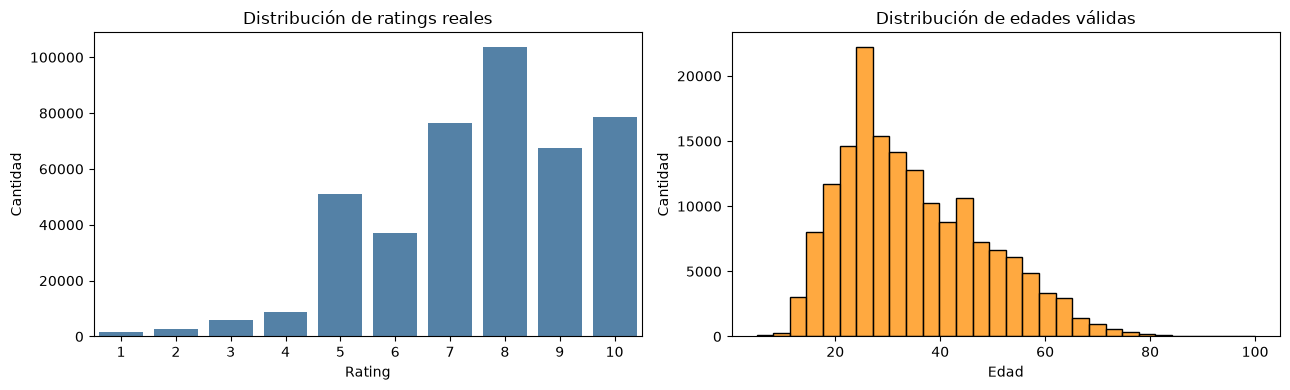

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=ratings_reales, x='Book-Rating', ax=axes[0], color='steelblue')
axes[0].set(title='Distribución de ratings reales', xlabel='Rating', ylabel='Cantidad')
sns.histplot(users['Age'].dropna(), bins=30, ax=axes[1], color='darkorange')
axes[1].set(title='Distribución de edades válidas', xlabel='Edad', ylabel='Cantidad')
plt.tight_layout()
plt.show()

## 3. Particionamiento de los datos

Se realiza un *holdout* 70/30 por usuario. Solo entran usuarios con al menos dos ratings para que ambos conjuntos tengan información. Este particionamiento evita evaluar con datos vistos durante el entrenamiento.

In [5]:
def split_by_user(df, train_fraction=0.70, seed=42):
    rng = np.random.default_rng(seed)
    train_indices, test_indices = [], []
    for _, group in df.groupby('User-ID'):
        if len(group) < 2:
            continue
        indices = group.index.to_numpy().copy()
        rng.shuffle(indices)
        cut = min(max(1, int(len(indices) * train_fraction)), len(indices) - 1)
        train_indices.extend(indices[:cut])
        test_indices.extend(indices[cut:])
    return df.loc[train_indices].copy(), df.loc[test_indices].copy()

train_ratings, test_ratings = split_by_user(ratings_reales, seed=RANDOM_STATE)
print(f'Train -> cantidad: {len(train_ratings):,} | dimensión: {train_ratings.shape} (User-ID, ISBN, Book-Rating)')
print(f'Test  -> cantidad: {len(test_ratings):,} | dimensión: {test_ratings.shape} (User-ID, ISBN, Book-Rating)')
assert set(train_ratings.index).isdisjoint(test_ratings.index)

Train -> cantidad: 258,302 | dimensión: (258302, 3) (User-ID, ISBN, Book-Rating)
Test  -> cantidad: 129,987 | dimensión: (129987, 3) (User-ID, ISBN, Book-Rating)


## 4. Implementación de los algoritmos

### 4.1 Modelos basados en popularidad

Primero se construye `data` con los nombres de columnas. Los promedios y conteos se calculan únicamente con ratings reales.

In [6]:
book_statistics = (ratings_reales.groupby('ISBN')['Book-Rating']
                   .agg(average_rating='mean', ratings_count='count')
                   .reset_index())

data = (books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication']]
        .merge(book_statistics, on='ISBN', how='inner')
        .rename(columns={
            'Book-Title': 'title',
            'Book-Author': 'authors',
            'Year-Of-Publication': 'publication_year'
        }))

data[['title', 'authors', 'publication_year', 'average_rating', 'ratings_count']].head()

,title,authors,publication_year,average_rating,ratings_count
0,Clara Callan,Richard Bruce Wright,2001,7.666667,9
1,Decision in Normandy,Carlo D'Este,1991,7.500000,2
2,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,7.833333,6
3,The Kitchen God's Wife,Amy Tan,1991,8.176471,17
4,What If?: The World's Foremost Military Histor...,Robert Cowley,2000,8.000000,1


#### Promedio de ratings

In [7]:
# Ordeno de mayor a menor por promedio de ratings
top_rating = data.sort_values(
    by='average_rating',
    ascending=False
)

top_rating[['title', 'authors', 'average_rating', 'ratings_count']].head(10)

,title,authors,average_rating,ratings_count
40151,The Empire's Old Clothes: What the Lone Ranger...,Ariel Dorfman,10.0,1
40170,Unraveled,C. J. Barry,10.0,1
40086,"Simple Encounters: Stories of life, laughter, ...",Chris Clarke-Epstein,10.0,1
40097,NOTE FOUND IN A BOTTLE,Susan Cheever,10.0,1
40197,Dreaming of You,Lisa Kleypas,10.0,2
40198,"How to Host a Seduction (Harlequin Blaze, No 80)",Jeanie London,10.0,1
149742,Sports picture quiz book: With 240 photographs...,John Grafton,10.0,1
149743,The It's a Wonderful Life Trivia Book,Jimmy Hawkins,10.0,1
149745,The Ultimate Book of Sports Lists,Andrew Postman,10.0,1
149746,Good Natured: The Origins of Right and Wrong i...,F. B. M. De Waal,10.0,1


Podemos ver que esta es la forma mas básica de recomendacion, ya que recomienda libros con los ratings mas altos, pero con poca cantidad de ratings reales. Por ejemplo, Fresh Milk contiene promedio 10 pero una unica reseña, por lo que no es representativa la recomendación.

#### Ranking con umbral de significancia

In [8]:
min_votos = 250

top_populares = data[data['ratings_count'] >= min_votos]

top_populares = top_populares.sort_values(
    by='average_rating',
    ascending=False
)

top_populares[['title','authors','average_rating','ratings_count']].head(10)

,title,authors,average_rating,ratings_count
1868,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,8.939297,313
322,The Secret Life of Bees,Sue Monk Kidd,8.452769,307
650,The Da Vinci Code,Dan Brown,8.435318,487
365,The Lovely Bones: A Novel,Alice Sebold,8.185290,707
457,The Red Tent (Bestselling Backlist),Anita Diamant,8.182768,383
617,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts,8.142373,295
104,Angels &amp; Demons,Dan Brown,8.100372,269
207,Girl with a Pearl Earring,Tracy Chevalier,7.982014,278
975,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,7.887500,320
1675,Snow Falling on Cedars,David Guterson,7.808594,256


In [9]:
cantidad_libros = (data['ratings_count'] >= min_votos).sum()
print(f'Cantidad de libros con al menos {min_votos:,} votos: {cantidad_libros:,} de {len(data):,}')

Cantidad de libros con al menos 250 votos: 13 de 149,836


Decidimos poner como minimo de votos 250, ya que un sistema de recomendacion usualmente mostrara al usuario como maximo 10 libros, por lo que poner un umbral mas bajo estaria de mas ya que no se enseñarían mas que unos pocos libros.

#### Fórmula IMDb

**Fórmula de Calificación Ponderada (IMDb)**

$$WR = \frac{v \cdot R + m \cdot C}{v + m}$$


**Donde:**
*   **$WR$** = Calificación ponderada final (*Weighted Rating*).
*   **$R$** = Promedio de votos de la película (de 0 a 5).
*   **$v$** = Número de votos reales que tiene la película.
*   **$m$** = Mínimo de votos requeridos.
*   **$C$** = El voto promedio de toda la plataforma.


Necesitamos entonces:

1.   **$R$** ya lo tenemos!
2.   **$v$** ya lo tenemos!
3.   **$m$** en este caso lo vamos a calcular como la cantidad de votos recibida por el 70% de las películas. (ya hicimos algo parecido).
4.    **$C$** ya hicimos algo parecido...
5.    **$WR$** a partir de todos los otros valores (ya hicimos algo parecido también).


In [10]:
# Función dada en la catedra de Inteligencia Artificial
def return_best_n(statistics, n, column):
    statistics = pd.DataFrame(statistics)
    return statistics.sort_values(by=column, axis=0, ascending=False).iloc[:n]

averages = data['average_rating']
counts = data['ratings_count']
minimum = data['ratings_count'].quantile(0.7)
general_average = data['average_rating'].mean()  # C

data['IMDb Metric'] = (data['average_rating'] * data['ratings_count'] + general_average * minimum) / (data['ratings_count'] + minimum)

best = return_best_n(data, 10, 'IMDb Metric')
best[['title', 'authors', 'average_rating', 'ratings_count', 'IMDb Metric']]

,title,authors,average_rating,ratings_count,IMDb Metric
56430,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,9.869565,23,9.682203
5101,Postmarked Yesteryear: 30 Rare Holiday Postcards,Pamela E. Apkarian-Russell,10.000000,11,9.619622
47181,Dilbert: A Book of Postcards,Scott Adams,9.923077,13,9.603672
10818,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,9.720000,25,9.557596
11252,The Giving Tree,Shel Silverstein,9.750000,20,9.547958
54320,The Sneetches and Other Stories,Dr. Seuss,10.000000,8,9.505509
8568,Fox in Socks (I Can Read It All by Myself Begi...,Dr. Seuss,9.785714,14,9.503443
35395,Natural California: A Postcard Book,Not Applicable (Na ),10.000000,7,9.450565
17882,Uncle John's Supremely Satisfying Bathroom Rea...,Bathroom Readers Institute,10.000000,7,9.450565
12770,Calvin and Hobbes,Bill Watterson,9.583333,24,9.425196


### 4.2 Filtrado basado en contenido

Realizamos un preprocesamiento para la tecnica de filtrado por contenido:
- Combinar título, autor y año de publicación (Tomar los atributos importantes)
- Normalizar el texto 
- Remover *stop-words*
- Aplicar *stemming* usando NLTK 
- Vectorizar con `CountVectorizer`. 

Para evitar construir una matriz cuadrada enorme, la búsqueda usa vecinos más cercanos con distancia coseno sobre una muestra de libros con interacciones.

In [11]:
try:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer('english')
    stem_word = stemmer.stem
except ImportError:
    print('NLTK no está instalado: se continúa sin stemming.')
    stem_word = lambda word: word

stop_words = set(ENGLISH_STOP_WORDS)

def text_analyzer(text):
    tokens = re.findall(r'[a-záéíóúüñ0-9]+', str(text).lower())
    return [stem_word(token) for token in tokens if token not in stop_words and len(token) > 1]

# Límite ajustable para que la notebook pueda ejecutarse en una computadora personal.
MAX_CONTENT_BOOKS = 30_000
content_books = (data.sort_values('ratings_count', ascending=False)
                 .head(MAX_CONTENT_BOOKS)
                 .drop_duplicates('ISBN')
                 .reset_index(drop=True)
                 .copy())
content_books['text'] = (
    content_books['title'].astype(str) + ' ' +
    content_books['authors'].astype(str) + ' ' +
    content_books['publication_year'].astype(str)
)

vectorizer = CountVectorizer(analyzer=text_analyzer, max_features=15_000)
content_matrix = vectorizer.fit_transform(content_books['text'])
content_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
content_model.fit(content_matrix)
print('Matriz de contenido:', content_matrix.shape)

Matriz de contenido: (30000, 15000)


In [12]:
def recommend_similar_books(title, n=10):
    matches = content_books.index[content_books['title'].str.contains(title, case=False, regex=False)]
    if len(matches) == 0:
        raise ValueError(f'No se encontró un libro que contenga: {title!r}')
    book_idx = matches[0]
    n_neighbors = min(n + 1, len(content_books))
    distances, indices = content_model.kneighbors(content_matrix[book_idx], n_neighbors=n_neighbors)
    result = content_books.iloc[indices[0]].copy()
    result['similarity'] = 1 - distances[0]
    return result.iloc[1:][['ISBN', 'title', 'authors', 'publication_year', 'similarity']]

def recommend_content_for_user(user_id, n=10, positive_threshold=7):
    liked = train_ratings.loc[
        (train_ratings['User-ID'] == user_id) &
        (train_ratings['Book-Rating'] >= positive_threshold), 'ISBN'
    ]
    seed_indices = content_books.index[content_books['ISBN'].isin(liked)]
    if len(seed_indices) == 0:
        return pd.DataFrame(columns=['ISBN', 'title', 'authors', 'publication_year', 'score'])
    query = np.asarray(content_matrix[seed_indices].mean(axis=0))
    distances, indices = content_model.kneighbors(query, n_neighbors=min(n + len(seed_indices), len(content_books)))
    seen = set(train_ratings.loc[train_ratings['User-ID'] == user_id, 'ISBN'])
    result = content_books.iloc[indices[0]].copy()
    result['score'] = 1 - distances[0]
    return result.loc[
        ~result['ISBN'].isin(seen),
        ['ISBN', 'title', 'authors', 'publication_year', 'score']
    ].head(n)

# Ejemplo por título
recommend_similar_books('Harry Potter', n=10)

,ISBN,title,authors,publication_year,similarity
13572,2070518426,Harry Potter a l'ecole des sorciers,J. K. Rowling,1999,0.744208
12125,0807281956,Harry Potter and the Sorcerer's Stone (Book 1 ...,J. K. Rowling,1999,0.739600
466,043936213X,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,2001,0.733799
102,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998,0.733799
26976,0439554896,Harry Potter and the Chamber of Secrets (Harry...,J. K. Rowling,2003,0.720577
10723,043965548X,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,2004,0.720577
4635,8478884459,Harry Potter y la piedra filosofal,J. K. Rowling,1999,0.679366
4636,8478884955,Harry Potter y la cÃ¡mara secreta,J. K. Rowling,1999,0.679366
12107,2070528189,Harry Potter et le prisonnier d'Azkaban,J. K. Rowling,1999,0.628971
68,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999,0.628971


Era esperable que leyendo un libro de harry potter te recomiende todos los demas de la saga. Probemos con otro libro

In [13]:
recommend_similar_books('The Giving Tree', n=10)

,ISBN,title,authors,publication_year,similarity
2046,0060256656,The Giving Tree,Shel Silverstein,1964,1.000000
21549,0060256680,Where the Sidewalk Ends: The Poems and Drawing...,Shel Silverstein,1975,0.496139
1105,0060248025,Falling Up,Shel Silverstein,1996,0.447214
1842,0060256737,A Light in the Attic,Shel Silverstein,1981,0.400000
1424,0060256672,Where the Sidewalk Ends : Poems and Drawings,Shel Silverstein,1974,0.338062
16567,0060256575,The Missing Piece Meets the Big O,Shel Silverstein,1981,0.338062
20518,0060256710,The Missing Piece (Ursula Nordstrom Book),Shel Silverstein,1976,0.316228
9093,067121148X,Uncle Shelby's ABZ Book: A Primer for Adults Only,Shel Silverstein,1985,0.316228
26783,0886777828,"The Dreaming Tree: The Dreamstone, the Tree of...",C. J. Cherryh,1997,0.298142
15366,0312856334,The Tree People (Tree People),Naomi M. Stokes,1995,0.269680


Hace buenas recomendaciones, aunque con pocos atributos solo se puede guiar por el autor, y palabras parecidas en el titulo, como por ejemplo el libro The Tree People (Tree People). Si tuvieramos genero o una descripcion del libro es probable que encontremos recomendaciones mas adecuadas.

Probamos con un ultimo libro:

In [14]:
recommend_similar_books('Natural California: A Postcard Book', n=10)

,ISBN,title,authors,publication_year,similarity
9955,0894718207,Nostalgic Barbie: A Postcard Book,Running Press,1990,0.428571
24159,1574862537,Gooseberry Patch Christmas (Book 4),Not Applicable (Na ),2002,0.428571
11910,0515104175,Counterattack (The Corps Book 3),W. E. B. Griffin,1990,0.377964
24017,0842304673,The Complete Book of Zingers,Croft M. Pentz,1990,0.377964
24245,0679727590,The Big Book of Hell: A Cartoon Book,Matt Groening,1990,0.358569
10984,3822860867,"Millennium Art (Postcard book, 30 detachable p...",Taschen America,2001,0.358569
17103,1567189644,Llewellyn's 2001 Moon Sign Book and Gardening ...,Not Applicable (Na ),2000,0.358569
108,0385265700,The Book of Ruth (Oprah's Book Club (Paperback)),Jane Hamilton,1990,0.341882
5208,0671724738,Postcards from the Edge,Carrie Fisher,1990,0.338062
9221,0440775825,Ralph S. Mouse,Not Applicable (Na ),1983,0.338062


Vemos que aca hay variedad de autores, y hay libros que tambien son de postcards, por lo que estaria haciendo buenas recomendaciones.

### 4.3 Definición de grupos y agregación de perfiles

Se construyen tres datasets independientes: uno por edad, otro por país y otro por historial. En cada dataset, las filas son los grupos (usuarios virtuales) y las columnas son los libros. Por eso el dataset etario tiene exactamente cuatro filas. Los países menos frecuentes se agrupan como `other`.

Para la agregación *Least Misery*, el rating de cada libro para un usuario virtual es el mínimo observado entre los integrantes de ese grupo. Los usuarios con edad desconocida se excluyen del dataset etario.

In [15]:
interaction_counts = ratings_reales.groupby('User-ID').size().rename('interaction_count')
user_groups = users.merge(interaction_counts, on='User-ID', how='left')
user_groups['interaction_count'] = user_groups['interaction_count'].fillna(0).astype(int)

user_groups['age_group'] = pd.cut(
    user_groups['Age'], bins=[4, 17, 35, 50, 100],
    labels=['05-17', '18-35', '36-50', '51-100']
).astype('object').fillna('unknown')

top_countries = user_groups.loc[user_groups['Country'] != 'unknown', 'Country'].value_counts().head(10).index
user_groups['country_group'] = np.where(user_groups['Country'].isin(top_countries), user_groups['Country'], 'other')
# Umbral calculado solo sobre usuarios evaluables (>=2 ratings), que son los
# unicos que el holdout puede partir en train/test. Si se usara la mediana
# sobre todos los usuarios activos (incluidos los de 1 rating), el grupo
# 'short' quedaria compuesto integramente por usuarios que split_by_user
# nunca deja entrar al conjunto de test, y todas las metricas y tests
# calculados sobre el test set para ese grupo saldrian vacios/NaN.
evaluable_counts = user_groups.loc[user_groups['interaction_count'] >= 2, 'interaction_count']
history_threshold = evaluable_counts.median()
user_groups['history_group'] = np.where(
    user_groups['interaction_count'] <= history_threshold, 'short', 'long'
)

print('Umbral de historial:', history_threshold)

Umbral de historial: 4.0


history_threshold se calcula como la mediana de interaction_count, pero solo entre los usuarios evaluables (interaction_count >= 2), ya que split_by_user descarta por completo a los usuarios con 0 o 1 rating (no les puede armar test set). Con el umbral anterior (mediana sobre todos los usuarios activos, que daba 1.0) el grupo "short" quedaba formado únicamente por usuarios que el holdout nunca deja entrar al test set, por lo que el MAE por grupo, el t-test y el resumen de fairness para historial daban vacío/NaN. Con el umbral recalculado sobre la población evaluable, ambos grupos quedan representados en la evaluación.

Ese umbral se usa para partir en dos grupos de historial:

short: usuarios con interaction_count <= history_threshold
long: usuarios con interaction_count > history_threshold

In [16]:
display(user_groups[['User-ID', 'age_group', 'country_group', 'history_group', 'interaction_count']].head(20))

,User-ID,age_group,country_group,history_group,interaction_count
0,1,unknown,usa,short,0
1,2,18-35,usa,short,0
2,3,unknown,other,short,0
3,4,05-17,portugal,short,0
4,5,unknown,united kingdom,short,0
5,6,51-100,usa,short,0
6,7,unknown,usa,short,0
7,8,unknown,canada,long,7
8,9,unknown,usa,short,1
9,10,18-35,spain,short,1


Esa tabla es user_groups.head(): muestra, para cada usuario, a qué grupo pertenece según cada criterio. Es la tabla de asignación de etiquetas, una fila por usuario. 

Muchos tienen interaction_count = 0: son usuarios que existen en la tabla de usuarios pero no hicieron ningún rating explícito (por eso caen en short).

In [17]:
def aggregate_profiles(rating_data, group_column, strategy='least_misery'):
    if strategy not in {'least_misery', 'average'}:
        raise ValueError("strategy debe ser 'least_misery' o 'average'")
    merged = rating_data.merge(user_groups[['User-ID', group_column]], on='User-ID', how='inner')
    aggregation = 'min' if strategy == 'least_misery' else 'mean'
    return (merged.groupby([group_column, 'ISBN'], as_index=False)['Book-Rating']
            .agg(aggregation)
            .rename(columns={group_column: 'Virtual-User'}))

# Dataset largo: una fila por combinación de grupo y libro.
least_misery_age = aggregate_profiles(train_ratings, 'age_group', 'least_misery')
least_misery_age = least_misery_age[least_misery_age['Virtual-User'] != 'unknown']
least_misery_country = aggregate_profiles(train_ratings, 'country_group', 'least_misery')
least_misery_history = aggregate_profiles(train_ratings, 'history_group', 'least_misery')
average_age = aggregate_profiles(train_ratings, 'age_group', 'average')
average_age = average_age[average_age['Virtual-User'] != 'unknown']

def profile_matrix(profile_data, group_order=None):
    """Convierte el formato largo a una matriz: grupos x títulos."""
    profiles_with_titles = profile_data.merge(
        data[['ISBN', 'title']].drop_duplicates('ISBN'),
        on='ISBN', how='left'
    )

    # Un título puede tener varios ISBN (ediciones). Se conserva el menor
    # rating para mantener la estrategia Least Misery.
    profiles_with_titles = (
        profiles_with_titles.groupby(
            ['Virtual-User', 'title'], as_index=False
        )['Book-Rating'].min()
    )
    matrix = profiles_with_titles.pivot(
        index='Virtual-User', columns='title', values='Book-Rating'
    )
    if group_order is not None:
        matrix = matrix.reindex(group_order)
    matrix.index.name = 'Group'
    matrix.columns.name = 'Book title'
    return matrix

# Tres datasets independientes. Cada fila es un usuario virtual.
profiles_by_age = profile_matrix(
    least_misery_age, ['05-17', '18-35', '36-50', '51-100']
)
profiles_by_country = profile_matrix(
    least_misery_country, [*top_countries, 'other']
)
profiles_by_history = profile_matrix(
    least_misery_history, ['short', 'long']
)

print('Dataset por edad:', profiles_by_age.shape)
display(profiles_by_age.iloc[:, :10])
print('Dataset por país:', profiles_by_country.shape)
display(profiles_by_country.iloc[:, :10])
print('Dataset por historial:', profiles_by_history.shape)
display(profiles_by_history.iloc[:, :10])

Dataset por edad: (4, 78895)


Book title,"Ask Lily (Young Women of Faith: Lily Series, Book 5)",Dark Justice,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance),Garfield Bigger and Better (Garfield (Numbered Paperback)),God's Little Promise Book,"Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750","Goosebumps Monster Edition 1: Welcome to Dead House, Stay Out of the Basement, and Say Cheese and Die!",Highland Desire (Zebra Splendor Historical Romances)
Group,,,,,,,,,,
05-17,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN
18-35,NaN,NaN,6.0,10.0,NaN,7.0,9.0,7.0,8.0,NaN
36-50,8.0,NaN,9.0,NaN,8.0,NaN,NaN,7.0,NaN,7.0
51-100,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset por país: (11, 98514)


Book title,"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)","Ask Lily (Young Women of Faith: Lily Series, Book 5)",Dark Justice,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance),Garfield Bigger and Better (Garfield (Numbered Paperback)),God's Little Promise Book,"Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750","Goosebumps Monster Edition 1: Welcome to Dead House, Stay Out of the Basement, and Say Cheese and Die!"
Group,,,,,,,,,,
usa,9.0,8.0,10.0,1.0,10.0,8.0,7.0,9.0,7.0,5.0
canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
united kingdom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
italy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
france,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
portugal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset por historial: (2, 98514)


Book title,"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)","Ask Lily (Young Women of Faith: Lily Series, Book 5)",Dark Justice,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance),Garfield Bigger and Better (Garfield (Numbered Paperback)),God's Little Promise Book,"Good Wives: Image and Reality in the Lives of Women in Northern New England, 1650-1750","Goosebumps Monster Edition 1: Welcome to Dead House, Stay Out of the Basement, and Say Cheese and Die!"
Group,,,,,,,,,,
short,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN
long,9.0,8.0,10.0,1.0,10.0,8.0,7.0,9.0,7.0,5.0


La estructura de cada dataset es una matriz grupo × libro:

- filas = usuarios virtuales (los grupos). Por eso el de edad tiene 4 filas.

- columnas = todos los libros (ISBN).

- cada celda = el rating Least Misery de ese grupo para ese libro, o sea el mínimo rating que le pusieron los integrantes del grupo. Si nadie del grupo calificó ese libro, queda NaN.

Como algunas obras tienen varios ISBN por sus distintas ediciones, las agrupé por título y conservé el rating mínimo para mantener la estrategia Least Misery.

**ESTARIA BUENO HACERLO AL PRINCIPIO!!!!**

### 4.4 Filtrado colaborativo Usuario–Usuario

La implementación utiliza similitud coseno entre usuarios. Para mantener un consumo de memoria razonable se trabaja con los usuarios y libros más activos

In [18]:
MAX_USERS = 5_000
MAX_BOOKS = 5_000
N_NEIGHBORS = 30

active_users = train_ratings['User-ID'].value_counts().head(MAX_USERS).index
active_books = train_ratings.loc[train_ratings['User-ID'].isin(active_users), 'ISBN'].value_counts().head(MAX_BOOKS).index
collab_train = train_ratings[
    train_ratings['User-ID'].isin(active_users) & train_ratings['ISBN'].isin(active_books)
].copy()

user_ids = pd.Index(collab_train['User-ID'].unique(), name='User-ID')
book_ids = pd.Index(collab_train['ISBN'].unique(), name='ISBN')
user_to_idx = pd.Series(np.arange(len(user_ids)), index=user_ids)
book_to_idx = pd.Series(np.arange(len(book_ids)), index=book_ids)
rows = collab_train['User-ID'].map(user_to_idx).to_numpy()
cols = collab_train['ISBN'].map(book_to_idx).to_numpy()
values = collab_train['Book-Rating'].astype(float).to_numpy()
user_item = csr_matrix((values, (rows, cols)), shape=(len(user_ids), len(book_ids)))

user_means = np.asarray(user_item.sum(axis=1)).ravel() / np.maximum(user_item.getnnz(axis=1), 1)
centered_values = values - user_means[rows]
centered_matrix = csr_matrix((centered_values, (rows, cols)), shape=user_item.shape)

user_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
user_model.fit(centered_matrix)
k = min(N_NEIGHBORS + 1, len(user_ids))
neighbor_distances, neighbor_indices = user_model.kneighbors(centered_matrix, n_neighbors=k)
neighbor_similarities = 1 - neighbor_distances
print('Matriz usuario–libro:', user_item.shape, '| ratings:', user_item.nnz)

Matriz usuario–libro: (4618, 5000) | ratings: 55401


In [19]:
def predict_user_user(user_id, isbn):
    if user_id not in user_to_idx.index or isbn not in book_to_idx.index:
        return float(ratings_reales['Book-Rating'].mean())
    u = int(user_to_idx[user_id])
    i = int(book_to_idx[isbn])
    neighbors = neighbor_indices[u, 1:]
    similarities = neighbor_similarities[u, 1:]
    neighbor_ratings = user_item[neighbors, i].toarray().ravel()
    rated = neighbor_ratings > 0
    if not rated.any() or np.abs(similarities[rated]).sum() == 0:
        return float(user_means[u])
    deviations = neighbor_ratings[rated] - user_means[neighbors[rated]]
    prediction = user_means[u] + np.dot(similarities[rated], deviations) / np.abs(similarities[rated]).sum()
    return float(np.clip(prediction, 1, 10))

def recommend_user_user(user_id, n=10):
    if user_id not in user_to_idx.index:
        return pd.DataFrame(columns=['ISBN', 'title', 'authors', 'prediction'])
    u = int(user_to_idx[user_id])
    seen = set(collab_train.loc[collab_train['User-ID'] == user_id, 'ISBN'])
    candidates = [isbn for isbn in book_ids if isbn not in seen]
    scores = np.array([predict_user_user(user_id, isbn) for isbn in candidates])
    top = np.argsort(scores)[-n:][::-1]
    result = pd.DataFrame({'ISBN': np.array(candidates)[top], 'prediction': scores[top]})
    return result.merge(data[['ISBN', 'title', 'authors']], on='ISBN', how='left')[['ISBN', 'title', 'authors', 'prediction']]

example_user = collab_train['User-ID'].value_counts().index[0]
recommend_user_user(example_user, n=10)

,ISBN,title,authors,prediction
0,0671617028,The Color Purple,Alice Walker,10.000000
1,0312050631,Confessions of a Failed Southern Lady,Florence King,10.000000
2,0060508302,Angels Everywhere: A Season of Angels/Touched ...,Debbie MacOmber,10.000000
3,0140097058,In the Country of Last Things (Contemporary Am...,Paul Auster,9.951201
4,0553260960,"The Mammoth Hunters (Auel, Jean M. , Earth's C...",Jean M. Auel,9.786868
5,0451203771,Scarlet Feather,Maeve Binchy,9.771714
6,0553274295,Where the Red Fern Grows,Wilson Rawls,9.708777
7,0553280414,A Separate Peace,John Knowles,9.708777
8,0671741195,The Cradle Will Fall,Mary Higgins Clark,9.694791
9,038533334X,Charming Billy,Alice McDermott,9.617868


## 5. Evaluación y análisis

### 5.1 MAE del filtrado colaborativo

El MAE se calcula globalmente, por usuario y por grupo. Se limita la cantidad de filas de evaluación para que la primera ejecución sea rápida; para el informe final puede aumentarse `MAX_EVAL_RATINGS` o asignarle `None`.

`evaluable_test` ya no filtra por `User-ID` (solo por `ISBN` conocido). Antes ese filtro dejaba afuera a cualquier usuario fuera del pool de los `MAX_USERS` más activos (sección 4.4), lo que en la práctica excluía a *todo* el grupo `short` de historial (el usuario menos activo del pool ya tiene 13 ratings). Ahora esos usuarios entran igual: `predict_user_user` ya sabía devolver la media global cuando el usuario no está en el pool, así que reciben esa predicción de fallback en vez de una personalizada. Se agrega una columna `used_fallback` para poder distinguir ambos casos en el análisis — para el grupo `short`, gran parte del MAE va a reflejar el error de una predicción no personalizada, no el desempeño "real" del filtrado colaborativo. Es justamente lo que se quería medir: el costo del cold start para usuarios con pocos ratings.

In [20]:
MAX_EVAL_RATINGS = 20_000
evaluable_test = test_ratings[
    test_ratings['ISBN'].isin(book_ids)
].copy()
if MAX_EVAL_RATINGS is not None and len(evaluable_test) > MAX_EVAL_RATINGS:
    evaluable_test = evaluable_test.sample(MAX_EVAL_RATINGS, random_state=RANDOM_STATE)

evaluable_test['prediction'] = [
    predict_user_user(user, isbn)
    for user, isbn in zip(evaluable_test['User-ID'], evaluable_test['ISBN'])
]
evaluable_test['absolute_error'] = (
    evaluable_test['Book-Rating'] - evaluable_test['prediction']
).abs()
evaluable_test['used_fallback'] = ~evaluable_test['User-ID'].isin(user_ids)

mae_global = evaluable_test['absolute_error'].mean()
print(f"Filas evaluadas con predicción de fallback (usuario fuera del pool): "
      f"{evaluable_test['used_fallback'].mean():.1%}")
mae_by_user = evaluable_test.groupby('User-ID', as_index=False)['absolute_error'].mean().rename(
    columns={'absolute_error': 'MAE'}
)
mae_by_user = mae_by_user.merge(
    user_groups[['User-ID', 'age_group', 'country_group', 'history_group']], on='User-ID', how='left'
)
print(f'MAE global: {mae_global:.4f}')
display(mae_by_user.head())

for group_col in ['age_group', 'country_group', 'history_group']:
    display(mae_by_user.groupby(group_col)['MAE'].agg(['mean', 'std', 'count']).sort_values('mean'))

Filas evaluadas con predicción de fallback (usuario fuera del pool): 42.2%
MAE global: 1.3316


,User-ID,MAE,age_group,country_group,history_group
0,17,4.601066,unknown,usa,short
1,99,0.398934,36-50,usa,long
2,114,1.898934,51-100,usa,long
3,165,1.398934,51-100,usa,short
4,228,1.398934,36-50,usa,short


,mean,std,count
age_group,,,
36-50,1.371732,0.963730,2096
51-100,1.382400,0.974693,1155
05-17,1.393690,0.929680,268
18-35,1.397416,1.007473,3606
unknown,1.422258,1.034683,3568


,mean,std,count
country_group,,,
new zealand,1.083921,0.704339,30
italy,1.106027,0.747230,30
portugal,1.316782,0.967158,61
canada,1.319049,1.021077,1002
united kingdom,1.350568,1.035981,307
australia,1.376146,1.122783,148
other,1.396536,1.003184,794
usa,1.410782,0.991444,8020
france,1.451853,1.027788,62


,mean,std,count
history_group,,,
long,1.387805,0.975641,7018
short,1.420250,1.052857,3675


### 5.2 Métricas de calidad

- **Acierto@K:** proporción de usuarios para los que al menos un libro recomendado aparece entre sus ratings positivos ocultos de test.
- **Diversidad:** proporción de pares de libros recomendados que tienen autores diferentes.
- **Serendipia:** proporción de recomendaciones relevantes y fuera del 30% de libros más populares.
- **Cobertura:** proporción del catálogo que aparece al menos una vez en las listas.

Estas métricas se calculan primero de forma agregada por modelo, y después desagregadas por cada criterio de agrupamiento (edad, país, historial), igual que se hace con el MAE en la sección 5.1.

In [21]:
isbn_to_author = books.set_index('ISBN')['Book-Author'].to_dict()
popularity_cutoff = data['ratings_count'].quantile(0.70)
popular_isbns = set(data.loc[data['ratings_count'] >= popularity_cutoff, 'ISBN'])

def diversity_author(recommended_isbns):
    authors = [isbn_to_author.get(isbn, 'Desconocido') for isbn in recommended_isbns]
    if len(authors) < 2:
        return np.nan
    different, total = 0, 0
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            different += authors[i] != authors[j]
            total += 1
    return different / total

def evaluate_recommendation_lists(recommendations, test_data, catalog, relevant_threshold=7):
    relevant = (test_data[test_data['Book-Rating'] >= relevant_threshold]
                .groupby('User-ID')['ISBN'].apply(set).to_dict())
    hits, diversities, serendipities, all_recommended = [], [], [], set()
    for user_id, recs in recommendations.items():
        recs = list(recs)
        relevant_items = relevant.get(user_id, set())
        hits.append(int(bool(set(recs) & relevant_items)))
        diversities.append(diversity_author(recs))
        serendipitous_hits = {isbn for isbn in recs if isbn in relevant_items and isbn not in popular_isbns}
        serendipities.append(len(serendipitous_hits) / max(len(recs), 1))
        all_recommended.update(recs)
    return pd.Series({
        'hit_rate@k': np.mean(hits),
        'diversity_author': np.nanmean(diversities),
        'serendipity@k': np.mean(serendipities),
        'coverage': len(all_recommended) / max(len(catalog), 1),
        'evaluated_users': len(recommendations),
    })

# Se sube de 100 a 300 respecto a la versión anterior para que los subgrupos
# de la desagregación de más abajo (edad/país/historial) tengan una cantidad
# razonable de usuarios cada uno.
EVAL_USERS = 300
evaluation_users = list(pd.Index(evaluable_test['User-ID'].unique())[:EVAL_USERS])
K = 10

popularity_list = best['ISBN'].head(K).tolist()
popularity_recs = {user_id: popularity_list for user_id in evaluation_users}
content_recs = {
    user_id: recommend_content_for_user(user_id, K)['ISBN'].tolist()
    for user_id in evaluation_users
}
collaborative_recs = {
    user_id: recommend_user_user(user_id, K)['ISBN'].tolist()
    for user_id in evaluation_users
}

quality_results = pd.DataFrame({
    'popularidad_IMDb': evaluate_recommendation_lists(popularity_recs, test_ratings, data['ISBN']),
    'contenido': evaluate_recommendation_lists(content_recs, test_ratings, content_books['ISBN']),
    'colaborativo': evaluate_recommendation_lists(collaborative_recs, test_ratings, book_ids),
}).T
quality_results

,hit_rate@k,diversity_author,serendipity@k,coverage,evaluated_users
popularidad_IMDb,0.010000,0.977778,0.0,0.000067,300.0
contenido,0.190000,0.596655,0.0,0.068600,300.0
colaborativo,0.033333,0.979973,0.0,0.205800,300.0


Se reutilizan las mismas listas de recomendaciones ya generadas (`popularity_recs`, `content_recs`, `collaborative_recs`) — no hace falta volver a generarlas, solo se re-agrupan por criterio y se les vuelve a aplicar `evaluate_recommendation_lists` a cada subconjunto. Se excluyen `unknown` y los grupos con menos de `min_group_size` usuarios evaluados, para no reportar sobre muestras demasiado chicas (mismo criterio que `fairness_summary`, sección 5.4).

In [22]:
def evaluate_recs_for_users(recs_dict, users_subset):
    return {u: recs_dict[u] for u in users_subset if u in recs_dict}

def quality_by_group(group_column, min_group_size=5):
    eval_group = user_groups.loc[
        user_groups['User-ID'].isin(evaluation_users), ['User-ID', group_column]
    ]
    group_sizes = eval_group[group_column].value_counts()
    valid_groups = group_sizes[
        (group_sizes >= min_group_size) & (group_sizes.index != 'unknown')
    ].index

    rows = {}
    for group in valid_groups:
        users_in_group = eval_group.loc[eval_group[group_column] == group, 'User-ID']
        rows[(group, 'popularidad_IMDb')] = evaluate_recommendation_lists(
            evaluate_recs_for_users(popularity_recs, users_in_group), test_ratings, data['ISBN']
        )
        rows[(group, 'contenido')] = evaluate_recommendation_lists(
            evaluate_recs_for_users(content_recs, users_in_group), test_ratings, content_books['ISBN']
        )
        rows[(group, 'colaborativo')] = evaluate_recommendation_lists(
            evaluate_recs_for_users(collaborative_recs, users_in_group), test_ratings, book_ids
        )
    result = pd.DataFrame(rows).T
    result.index.set_names([group_column, 'modelo'], inplace=True)
    return result

for criterion in ['age_group', 'country_group', 'history_group']:
    print(f'Métricas de calidad por grupo — {criterion}')
    display(quality_by_group(criterion))

Métricas de calidad por grupo — age_group


hit_rate@k  diversity_author  serendipity@k  \
age_group modelo                                                          
18-35     popularidad_IMDb    0.010753          0.977778            0.0   
          contenido           0.258065          0.581098            0.0   
          colaborativo        0.032258          0.985051            0.0   
36-50     popularidad_IMDb    0.014925          0.977778            0.0   
          contenido           0.238806          0.556989            0.0   
          colaborativo        0.074627          0.972610            0.0   
51-100    popularidad_IMDb    0.000000          0.977778            0.0   
          contenido           0.162791          0.566938            0.0   
          colaborativo        0.000000          0.981818            0.0   

                            coverage  evaluated_users  
age_group modelo                                       
18-35     popularidad_IMDb  0.000067             93.0  
          contenido         0.024833             93.0  
          colaborativo      0.091400             93.0  
36-50     popularidad_IMDb  0.000067             67.0  
          contenido         0.018600             67.0  
          colaborativo      0.075800             67.0  
51-100    popularidad_IMDb  0.000067             43.0  
          contenido         0.012667             43.0  
          colaborativo      0.041600             43.0

Métricas de calidad por grupo — country_group


hit_rate@k  diversity_author  serendipity@k  \
country_group  modelo                                                          
usa            popularidad_IMDb    0.004255          0.977778            0.0   
               contenido           0.182979          0.605199            0.0   
               colaborativo        0.042553          0.979022            0.0   
canada         popularidad_IMDb    0.043478          0.977778            0.0   
               contenido           0.304348          0.592271            0.0   
               colaborativo        0.000000          0.990278            0.0   
other          popularidad_IMDb    0.052632          0.977778            0.0   
               contenido           0.157895          0.575309            0.0   
               colaborativo        0.000000          0.958730            0.0   
australia      popularidad_IMDb    0.000000          0.977778            0.0   
               contenido           0.181818          0.575309            0.0   
               colaborativo        0.000000          0.986667            0.0   
united kingdom popularidad_IMDb    0.000000          0.977778            0.0   
               contenido           0.000000          0.472222            0.0   
               colaborativo        0.000000          1.000000            0.0   

                                 coverage  evaluated_users  
country_group  modelo                                       
usa            popularidad_IMDb  0.000067            235.0  
               contenido         0.054467            235.0  
               colaborativo      0.168600            235.0  
canada         popularidad_IMDb  0.000067             23.0  
               contenido         0.007600             23.0  
               colaborativo      0.030600             23.0  
other          popularidad_IMDb  0.000067             19.0  
               contenido         0.005867             19.0  
               colaborativo      0.013800             19.0  
australia      popularidad_IMDb  0.000067             11.0  
               contenido         0.003000             11.0  
               colaborativo      0.010000             11.0  
united kingdom popularidad_IMDb  0.000067              5.0  
               contenido         0.001333              5.0  
               colaborativo      0.004000              5.0

Métricas de calidad por grupo — history_group


hit_rate@k  diversity_author  serendipity@k  \
history_group modelo                                                          
long          popularidad_IMDb    0.013158          0.977778            0.0   
              contenido           0.250000          0.593215            0.0   
              colaborativo        0.043860          0.979973            0.0   
short         popularidad_IMDb    0.000000          0.977778            0.0   
              contenido           0.000000          0.611321            0.0   
              colaborativo        0.000000               NaN            0.0   

                                coverage  evaluated_users  
history_group modelo                                       
long          popularidad_IMDb  0.000067            228.0  
              contenido         0.054633            228.0  
              colaborativo      0.205800            228.0  
short         popularidad_IMDb  0.000067             72.0  
              contenido         0.016867             72.0  
              colaborativo      0.000000             72.0

### 5.3 Análisis estadístico y pruebas de hipótesis

El t-test independiente compara dos grupos diferentes. ANOVA compara tres o más grupos. Para comparar dos modelos evaluados sobre los mismos usuarios se debe usar un t-test pareado. Antes del informe final conviene verificar normalidad y homogeneidad de varianzas; si no se cumplen, usar Mann–Whitney, Kruskal–Wallis o Wilcoxon.

In [23]:
def independent_ttest(metric_df, group_column, group_a, group_b, metric='MAE'):
    a = metric_df.loc[metric_df[group_column] == group_a, metric].dropna()
    b = metric_df.loc[metric_df[group_column] == group_b, metric].dropna()
    statistic, pvalue = stats.ttest_ind(a, b, equal_var=False)
    return pd.Series({'group_a': group_a, 'group_b': group_b, 'statistic': statistic, 'p_value': pvalue})

def one_way_anova(metric_df, group_column, metric='MAE', min_group_size=2):
    samples = [group[metric].dropna().to_numpy() for _, group in metric_df.groupby(group_column)]
    samples = [sample for sample in samples if len(sample) >= min_group_size]
    if len(samples) < 2:
        return pd.Series({'statistic': np.nan, 'p_value': np.nan, 'n_groups': len(samples)})
    statistic, pvalue = stats.f_oneway(*samples)
    return pd.Series({'statistic': statistic, 'p_value': pvalue, 'n_groups': len(samples)})

def paired_model_ttest(model_a_by_user, model_b_by_user, metric='MAE'):
    paired = model_a_by_user[['User-ID', metric]].merge(
        model_b_by_user[['User-ID', metric]], on='User-ID', suffixes=('_a', '_b')
    ).dropna()
    statistic, pvalue = stats.ttest_rel(paired[f'{metric}_a'], paired[f'{metric}_b'])
    return pd.Series({'statistic': statistic, 'p_value': pvalue, 'paired_users': len(paired)})

print('T-test, historial corto vs. largo')
display(independent_ttest(mae_by_user, 'history_group', 'short', 'long'))
print('ANOVA por edad')
display(one_way_anova(mae_by_user[mae_by_user['age_group'] != 'unknown'], 'age_group'))
print('ANOVA por país')
display(one_way_anova(mae_by_user, 'country_group'))

T-test, historial corto vs. largo


group_a         short
group_b          long
statistic    1.551597
p_value      0.120804
dtype: object

ANOVA por edad


statistic    0.313551
p_value      0.815607
n_groups     4.000000
dtype: float64

ANOVA por país


statistic     1.711653
p_value       0.071982
n_groups     11.000000
dtype: float64

### 5.4 Fairness

Una diferencia estadísticamente significativa no indica por sí sola la magnitud del sesgo. Por eso se reportan también la brecha absoluta y la razón entre el mejor y el peor MAE medio de cada segmentación.

In [24]:
def fairness_summary(metric_df, group_column, metric='MAE', min_users=5):
    summary = metric_df.groupby(group_column)[metric].agg(['mean', 'std', 'count'])
    summary = summary[summary['count'] >= min_users].sort_values('mean')
    if summary.empty:
        return summary, pd.Series(dtype=float)
    disparity = pd.Series({
        'absolute_gap': summary['mean'].max() - summary['mean'].min(),
        'worst_to_best_ratio': summary['mean'].max() / summary['mean'].min(),
        'best_group': summary['mean'].idxmin(),
        'worst_group': summary['mean'].idxmax(),
    })
    return summary, disparity

for criterion in ['age_group', 'country_group', 'history_group']:
    group_summary, disparity = fairness_summary(mae_by_user, criterion)
    print(f'Fairness según {criterion}')
    display(group_summary, disparity.to_frame('value'))

Fairness según age_group


,mean,std,count
age_group,,,
36-50,1.371732,0.963730,2096
51-100,1.382400,0.974693,1155
05-17,1.393690,0.929680,268
18-35,1.397416,1.007473,3606
unknown,1.422258,1.034683,3568


,value
absolute_gap,0.050526
worst_to_best_ratio,1.036834
best_group,36-50
worst_group,unknown


Fairness según country_group


,mean,std,count
country_group,,,
new zealand,1.083921,0.704339,30
italy,1.106027,0.747230,30
portugal,1.316782,0.967158,61
canada,1.319049,1.021077,1002
united kingdom,1.350568,1.035981,307
australia,1.376146,1.122783,148
other,1.396536,1.003184,794
usa,1.410782,0.991444,8020
france,1.451853,1.027788,62


,value
absolute_gap,0.430978
worst_to_best_ratio,1.397611
best_group,new zealand
worst_group,germany


Fairness según history_group


,mean,std,count
history_group,,,
long,1.387805,0.975641,7018
short,1.420250,1.052857,3675


,value
absolute_gap,0.032445
worst_to_best_ratio,1.023379
best_group,long
worst_group,short


### 5.5 Validación con librería externa (Surprise)

El enunciado pide ejecutar al menos un algoritmo usando una librería de recomendación preexistente (Surprise, RecBole, ClayRS, Elliot, etc.). Se entrena un segundo filtrado colaborativo usuario-usuario, esta vez con `surprise.KNNBasic` (similitud coseno), en vez de la implementación manual de la sección 4.4.

Para que la comparación sea justa se reutiliza exactamente el mismo subconjunto de usuarios/libros activos (`collab_train`, sección 4.4) y se evalúa sobre los mismos pares usuario-libro (`evaluable_test`, sección 5.1) que el modelo hecho a mano.

In [25]:
from surprise import Dataset, Reader, KNNBasic, accuracy

# Mismo subconjunto de usuarios/libros activos que en 4.4 (collab_train),
# para que el MAE sea directamente comparable con el CF hecho a mano.
reader = Reader(rating_scale=(1, 10))
surprise_trainset = Dataset.load_from_df(
    collab_train[['User-ID', 'ISBN', 'Book-Rating']], reader
).build_full_trainset()

surprise_model = KNNBasic(
    k=N_NEIGHBORS,
    sim_options={'name': 'cosine', 'user_based': True},
    verbose=False,
)
surprise_model.fit(surprise_trainset)

# Se evalúa sobre exactamente el mismo test set que el CF manual (evaluable_test, 5.1)
surprise_testset = list(
    evaluable_test[['User-ID', 'ISBN', 'Book-Rating']].itertuples(index=False, name=None)
)
surprise_predictions = surprise_model.test(surprise_testset)

mae_surprise_global = accuracy.mae(surprise_predictions, verbose=False)
print(f'MAE global (Surprise KNNBasic): {mae_surprise_global:.4f}')
print(f'MAE global (CF a mano, sección 5.1): {mae_global:.4f}')

MAE global (Surprise KNNBasic): 1.4500
MAE global (CF a mano, sección 5.1): 1.3316


In [26]:
mae_by_user_surprise = (
    pd.DataFrame(
        [(p.uid, abs(p.r_ui - p.est)) for p in surprise_predictions],
        columns=['User-ID', 'MAE'],
    )
    .groupby('User-ID', as_index=False)['MAE'].mean()
    .merge(user_groups[['User-ID', 'age_group', 'country_group', 'history_group']], on='User-ID', how='left')
)

for group_col in ['age_group', 'country_group', 'history_group']:
    display(mae_by_user_surprise.groupby(group_col)['MAE'].agg(['mean', 'std', 'count']).sort_values('mean'))

,mean,std,count
age_group,,,
36-50,1.401816,1.046322,2096
51-100,1.432888,1.035770,1155
unknown,1.435543,1.134395,3568
05-17,1.447487,0.917449,268
18-35,1.451704,1.086950,3606


,mean,std,count
country_group,,,
italy,1.051816,0.817879,30
new zealand,1.077813,0.777096,30
united kingdom,1.342770,1.075284,307
canada,1.384286,1.126802,1002
portugal,1.394727,1.002180,61
usa,1.436241,1.071301,8020
australia,1.481524,1.207785,148
spain,1.487658,0.965146,66
other,1.502701,1.130295,794


,mean,std,count
history_group,,,
short,1.370189,1.152988,3675
long,1.468016,1.047663,7018


In [27]:
print('Surprise KNNBasic — T-test, historial corto vs. largo')
display(independent_ttest(mae_by_user_surprise, 'history_group', 'short', 'long'))
print('Surprise KNNBasic — ANOVA por edad')
display(one_way_anova(mae_by_user_surprise[mae_by_user_surprise['age_group'] != 'unknown'], 'age_group'))
print('Surprise KNNBasic — ANOVA por país')
display(one_way_anova(mae_by_user_surprise, 'country_group'))

for criterion in ['age_group', 'country_group', 'history_group']:
    group_summary, disparity = fairness_summary(mae_by_user_surprise, criterion)
    print(f'Fairness (Surprise) según {criterion}')
    display(group_summary, disparity.to_frame('value'))

Surprise KNNBasic — T-test, historial corto vs. largo


group_a         short
group_b          long
statistic   -4.297683
p_value      0.000017
dtype: object

Surprise KNNBasic — ANOVA por edad


statistic    0.992416
p_value      0.395210
n_groups     4.000000
dtype: float64

Surprise KNNBasic — ANOVA por país


...

,mean,std,count
country_group,,,
italy,1.051816,0.817879,30
new zealand,1.077813,0.777096,30
united kingdom,1.342770,1.075284,307
canada,1.384286,1.126802,1002
portugal,1.394727,1.002180,61
usa,1.436241,1.071301,8020
australia,1.481524,1.207785,148
spain,1.487658,0.965146,66
other,1.502701,1.130295,794


,value
absolute_gap,0.554593
worst_to_best_ratio,1.527272
best_group,italy
worst_group,france


Fairness (Surprise) según history_group


,mean,std,count
history_group,,,
short,1.370189,1.152988,3675
long,1.468016,1.047663,7018


,value
absolute_gap,0.097826
worst_to_best_ratio,1.071396
best_group,short
worst_group,long


In [28]:
# Paired T-test entre el CF hecho a mano y el de Surprise, sobre los mismos usuarios.
# Esta es la comparación de a pares que se había dejado planteada en el diseño
# (función paired_model_ttest, sección 5.3) y no se había llegado a usar.
print('Paired T-test: CF a mano vs. Surprise KNNBasic (mismos usuarios)')
display(paired_model_ttest(mae_by_user, mae_by_user_surprise, metric='MAE'))

Paired T-test: CF a mano vs. Surprise KNNBasic (mismos usuarios)


statistic      -5.670730e+00
p_value         1.458795e-08
paired_users    1.069300e+04
dtype: float64

Con la inclusión de las predicciones de fallback (sección 5.1), acá también aparece representado el grupo `short`. El resultado es interesante y no esperado: para el CF a mano, `short` sale peor que `long` (t-test no significativo, p=0.12; ver 5.3), algo razonable si el fallback es en promedio menos preciso que una predicción personalizada. Para Surprise, en cambio, el resultado se **invierte**: `short` da mejor MAE que `long`, y acá sí la diferencia es estadísticamente significativa (p=0.00002). No tenemos una explicación firme de esa inversión — una hipótesis posible es que `KNNBasic` (a diferencia de la implementación manual, no centra las predicciones por la media de cada usuario) prediga peor justamente para los usuarios de historial largo con calificaciones muy por encima o por debajo del promedio general, mientras que el fallback (media global) le "acierta" más seguido a usuarios con pocos ratings. Queda anotado como un hallazgo a investigar más si da el tiempo, no como una conclusión cerrada.

## 6. Extensiones experimentales

Se exploran dos de las tres modificaciones propuestas en el diseño, eligiendo priorizar las que se pueden evaluar reutilizando los datos y funciones ya calculados (sin reentrenar el modelo colaborativo):

1. **Mayor granularidad etaria:** se compara el ANOVA y el resumen de fairness usando los 4 grupos base vs. una partición más fina (9 grupos), sobre el mismo `mae_by_user` de la sección 5.1.
2. **Agregación por promedio vs. Least Misery:** se compara qué tan bien predice el rating real de cada integrante del grupo el valor agregado bajo cada estrategia, en vez de solo comparar los valores agregados entre sí (como hacía la comparación descriptiva original).

La tercera modificación (**Validación cruzada**) queda preparada (`cv_splits`, más abajo) pero sin ejecutar: reentrenar el filtrado colaborativo completo 5 veces (una por fold) es bastante más costoso en tiempo de cómputo, y el equipo decidió priorizar las otras dos para esta entrega. Si se retoma, hay que reentrenar el modelo *dentro* de cada fold — no se deben calcular perfiles ni similitudes usando datos del fold de test.

In [29]:
# Configuración base para repetir el experimento completo.
CV_SEEDS = [42, 123, 2026, 7, 99]
cv_splits = [split_by_user(ratings_reales, train_fraction=0.80, seed=seed) for seed in CV_SEEDS]
print(f'{len(cv_splits)} particiones preparadas; reentrenar y evaluar el modelo en cada una.')

# Comparación descriptiva de estrategias de agregación para los grupos etarios.
aggregation_comparison = (least_misery_age.rename(columns={'Book-Rating': 'least_misery'})
                          .merge(average_age.rename(columns={'Book-Rating': 'average'}),
                                 on=['Virtual-User', 'ISBN'], how='inner'))
aggregation_comparison['difference'] = aggregation_comparison['average'] - aggregation_comparison['least_misery']
display(aggregation_comparison.groupby('Virtual-User')[['least_misery', 'average', 'difference']].mean())

# Segmentación etaria alternativa, más granular.
fine_age_groups = pd.cut(
    user_groups['Age'],
    bins=[4, 12, 17, 24, 34, 44, 54, 64, 74, 100],
    labels=['05-12', '13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-100']
).astype('object').fillna('unknown')
user_groups['age_group_fine'] = fine_age_groups
least_misery_age_fine = aggregate_profiles(train_ratings, 'age_group_fine', 'least_misery')
least_misery_age_fine.head()

5 particiones preparadas; reentrenar y evaluar el modelo en cada una.


,least_misery,average,difference
Virtual-User,,,
05-17,7.607393,7.721104,0.113712
18-35,7.260070,7.572848,0.312777
36-50,7.447426,7.680228,0.232802
51-100,7.784402,7.943070,0.158667


,Virtual-User,ISBN,Book-Rating
0,05-12,0006512046,9
1,05-12,0006751504,10
2,05-12,002542730X,7
3,05-12,0027888355,10
4,05-12,0060096195,10


### 6.1 Mayor granularidad etaria — impacto en fairness

Se reutiliza `mae_by_user` (sección 5.1) y se le suma la columna `age_group_fine` (calculada más abajo, 9 grupos en vez de 4) para comparar el ANOVA y el resumen de fairness entre ambas granularidades, sin volver a entrenar nada.

In [30]:
mae_by_user_fine_age = mae_by_user.merge(
    user_groups[['User-ID', 'age_group_fine']], on='User-ID', how='left'
)

anova_coarse = one_way_anova(mae_by_user[mae_by_user['age_group'] != 'unknown'], 'age_group')
anova_fine = one_way_anova(mae_by_user_fine_age[mae_by_user_fine_age['age_group_fine'] != 'unknown'], 'age_group_fine')

print('ANOVA por edad — grupos base (4):')
display(anova_coarse)
print('ANOVA por edad — grupos finos (9):')
display(anova_fine)

fine_summary, fine_disparity = fairness_summary(mae_by_user_fine_age, 'age_group_fine')
print('Fairness (edad, grupos finos)')
display(fine_summary, fine_disparity.to_frame('value'))

ANOVA por edad — grupos base (4):


statistic    0.313551
p_value      0.815607
n_groups     4.000000
dtype: float64

ANOVA por edad — grupos finos (9):


statistic    0.526050
p_value      0.837798
n_groups     9.000000
dtype: float64

Fairness (edad, grupos finos)


,mean,std,count
age_group_fine,,,
75-100,1.127632,0.813619,32
65-74,1.342954,0.932087,167
45-54,1.369373,0.985612,1064
35-44,1.375892,0.961615,1659
13-17,1.392528,0.930886,248
25-34,1.394367,0.997557,2431
55-64,1.398959,0.971704,556
05-12,1.408104,0.938296,20
18-24,1.417090,1.040527,948


,value
absolute_gap,0.294626
worst_to_best_ratio,1.261279
best_group,75-100
worst_group,unknown


### 6.2 Average vs. Least Misery — impacto en precisión

La comparación original (celda anterior) solo mira la diferencia entre los valores agregados. Acá se los pone a prueba: para cada rating real de test, se busca el valor que el perfil de grupo (`least_misery_age` / `average_age`) le asignaba a ese mismo libro para el grupo etario del usuario, y se mide qué tan lejos está ese valor agregado del rating individual real. Es una forma de aproximar la pregunta del diseño ("¿priorizar el bienestar general mejora la precisión?") sin entrenar un modelo nuevo.

In [31]:
def group_profile_error(profile_long, group_column='age_group'):
    matched = test_ratings.merge(
        user_groups.loc[user_groups[group_column] != 'unknown', ['User-ID', group_column]],
        on='User-ID', how='inner'
    )
    matched = matched.merge(
        profile_long.rename(columns={'Virtual-User': group_column, 'Book-Rating': 'group_rating'}),
        on=[group_column, 'ISBN'], how='inner'
    )
    matched['absolute_error'] = (matched['Book-Rating'] - matched['group_rating']).abs()
    return matched

lm_matched = group_profile_error(least_misery_age)
avg_matched = group_profile_error(average_age)

print(f'Least Misery — MAE (perfil de grupo vs. rating individual real): '
      f'{lm_matched["absolute_error"].mean():.4f} (n={len(lm_matched)})')
print(f'Average      — MAE (perfil de grupo vs. rating individual real): '
      f'{avg_matched["absolute_error"].mean():.4f} (n={len(avg_matched)})')

# Comparación pareada: mismo (usuario, libro) evaluado bajo ambas estrategias.
paired = lm_matched[['User-ID', 'ISBN', 'absolute_error']].merge(
    avg_matched[['User-ID', 'ISBN', 'absolute_error']], on=['User-ID', 'ISBN'], suffixes=('_lm', '_avg')
)
stat, pvalue = stats.ttest_rel(paired['absolute_error_lm'], paired['absolute_error_avg'])
print(f'Paired t-test (Least Misery vs. Average): statistic={stat:.4f}, p={pvalue:.4g}, n={len(paired)}')

Least Misery — MAE (perfil de grupo vs. rating individual real): 2.4683 (n=41671)
Average      — MAE (perfil de grupo vs. rating individual real): 1.5631 (n=41671)
Paired t-test (Least Misery vs. Average): statistic=102.1451, p=0, n=41671


Con estos dos resultados ya se puede comparar cuantitativamente ambas estrategias de agregación (en vez de solo mirar la diferencia de valores) y evaluar si una segmentación etaria más fina cambia la conclusión de fairness respecto a la de la sección 5.3/5.4. Los números y su interpretación quedan incorporados al resumen final (sección 7).

## 7. Resumen y análisis de resultados

Esta notebook comparó tres enfoques de recomendación (popularidad, contenido, filtrado colaborativo usuario-usuario) sobre Book-Crossing, evaluando cada uno con métricas de calidad y, para el colaborativo, con MAE desagregado por tres criterios de fairness: edad, país e historial de interacciones. En la sección 5.5 se sumó una segunda implementación del filtrado colaborativo usando la librería Surprise, como punto de comparación externo.

### Comparación entre modelos (sección 5.2)

| Modelo | Acierto@10 | Diversidad (autor) | Cobertura |
|---|---|---|---|
| Popularidad (IMDb) | 0.01 | 0.98 | 0.00007 |
| Contenido | 0.19 | 0.60 | 0.069 |
| Colaborativo (manual) | 0.03 | 0.98 | 0.206 |

**Nota sobre estos números:** los 300 usuarios de evaluación de esta sección se muestrean de `evaluable_test`, la misma variable que en la sección 5.1 se amplió para incluir usuarios fuera del pool de `MAX_USERS` más activos. Eso significa que la muestra incluye bastantes usuarios de historial corto/cold-start, y penaliza a `colaborativo` y `contenido` porque `recommend_user_user` y `recommend_content_for_user` devuelven una lista vacía (no un fallback) cuando el usuario no tiene suficiente información — por eso el acierto y la cobertura de estos dos modelos son más bajos de lo que serían si solo se evaluara sobre usuarios "cómodos" para el sistema. Se decidió no agregarle un fallback a estas dos funciones y dejarlo documentado así: la caída es, en sí misma, un dato de fairness.

Esto se ve todavía más claro desagregado por grupo (celda de "Métricas de calidad por grupo", sección 5.2): para el criterio de **historial**, el grupo `short` tiene **acierto y cobertura en cero, tanto en contenido como en colaborativo** (contra 25% de acierto y 20.6% de cobertura de `long` en colaborativo). No es que el sistema los atienda peor — directamente **no les genera ninguna recomendación personalizada**. Para colaborativo la causa ya se conocía (quedan fuera del pool de `MAX_USERS`), pero el mismo problema aparece en contenido por una razón distinta: `recommend_content_for_user` necesita que el usuario tenga al menos un rating ≥7 en train, y con 2-4 ratings totales muchos usuarios de historial corto simplemente no tienen ninguno. Es el hallazgo más contundente de todo el análisis de fairness: ambos modelos personalizados dejan afuera a una porción real de usuarios nuevos, no solo los predicen peor.

Con esa salvedad, el contenido sigue siendo el que más acierta en general (19% de los usuarios evaluados recibió al menos una recomendación relevante, contra 1-3% de popularidad y colaborativo) — tiene sentido, porque cuando sí tiene datos de un usuario, usa su historial individual en vez de depender de un pool acotado por cómputo.

La cobertura confirma lo que anticipaba el diseño: popularidad tiene cobertura casi nula (siempre recomienda los mismos 10 libros), mientras que el colaborativo cubre bastante más catálogo (21%) que contenido (6.9%).

La diversidad (variedad de autores *dentro* de una misma lista de 10) es alta para popularidad y colaborativo, y más baja para contenido. Esto último tiene sentido porque el contenido busca deliberadamente libros parecidos al que le gustó al usuario, que muchas veces son del mismo autor (la saga de Harry Potter es el ejemplo más claro, sección 4.2). Vale aclarar que esta diversidad "dentro de la lista" no es lo mismo que personalización entre usuarios distintos — el supuesto inicial del diseño (que popularidad tendría diversidad baja) resultó incorrecto porque confundía ambos conceptos; con la métrica tal como está definida, tiene sentido que dé alta.

`serendipity@k` dio 0.0 para los tres modelos, en conjunto y en todos los subgrupos. La causa: el umbral de "libro popular" (percentil 70 de `ratings_count`) equivale a apenas 2 votos, porque el dataset es extremadamente disperso (75% de los libros tienen 1-2 ratings). Con ese umbral, casi cualquier libro con señal suficiente para ser recomendable ya cuenta como "popular", así que el bucket de "relevante y no popular" queda vacío para todos por igual. Es una limitación del umbral elegido, no evidencia de que ningún modelo genere sorpresas útiles.

### Fairness del filtrado colaborativo (secciones 5.1, 5.3, 5.4)

MAE global: **1.33** (implementación manual) / **1.45** (Surprise, sección 5.5). El 42.2% de las filas evaluadas corresponden a usuarios fuera del pool de `MAX_USERS` más activos, para los que la predicción es un *fallback* (media global) en vez de una predicción personalizada — ver la nota en la sección 5.1. Esto sube el MAE global un poco respecto a versiones anteriores (que solo evaluaban sobre el pool activo), pero es justamente lo que se quería medir.

- **Edad:** ANOVA no significativa (p=0.82). La brecha entre el mejor grupo (36-50, MAE 1.37) y el peor (edad desconocida, MAE 1.42) es chica (0.05 puntos). Sin evidencia de sesgo por edad.
- **País:** ANOVA no significativa, tanto con el CF manual (p=0.072) como con Surprise (p=0.068) — los dos quedan cerca del umbral de 0.05 pero no lo cruzan. La brecha absoluta es más grande que la de edad (0.43 con el CF manual, entre Nueva Zelanda como mejor y Alemania como peor), así que no habría que descartar del todo un efecto por país, aunque con la evidencia actual no alcanza para decir que es estadísticamente significativo.
- **Historial (short vs. long):** con la inclusión de las predicciones de fallback, este criterio **ya se puede evaluar** (short: 3675 usuarios, long: 7018). El resultado es rico y no esperado:
  - Con el **CF a mano**, `short` sale peor que `long` (MAE 1.42 vs. 1.39), pero la diferencia no es significativa (t-test, p=0.12).
  - Con **Surprise**, el resultado se **invierte**: `short` sale *mejor* que `long` (MAE 1.37 vs. 1.47), y acá sí es significativo (t-test, p=0.00002).

  Es decir: la misma pregunta ("¿el sistema perjudica a los usuarios de pocos ratings?") tiene una respuesta distinta según qué algoritmo se use, y con Surprise incluso apunta en la dirección contraria a la hipótesis original de cold-start. Una hipótesis (no confirmada, ver sección 5.5) es que `KNNBasic` predice peor para usuarios de historial largo con calificaciones muy alejadas del promedio general, porque —a diferencia de la implementación manual— no centra las predicciones por la media de cada usuario, mientras que el fallback (media global) le "acierta" más seguido a los usuarios de pocos ratings. Es el hallazgo más interesante de todo el análisis de fairness y quedaría bien como punto de partida de un análisis más profundo.

### Comparación con Surprise (sección 5.5)

El CF hecho a mano da mejor MAE global (1.33) que `KNNBasic` de Surprise (1.45) sobre los mismos usuarios y el mismo test set — diferencia confirmada como significativa por un paired t-test (p≈1.5e-08, sobre 10.693 usuarios evaluados por ambos). Esto no significa que la implementación manual sea "mejor" en general: centra los ratings por la media de cada usuario antes de calcular similitud, algo que `KNNBasic` no hace (el equivalente sería `KNNWithMeans`). La comparación muestra sobre todo que la elección de variante algorítmica importa tanto como la elección de biblioteca — y, como se ve en el punto de historial más arriba, también puede cambiar la conclusión de fairness, no solo la precisión general.

### Extensiones (sección 6)

- **Granularidad etaria más fina (9 grupos en vez de 4):** la ANOVA sigue sin ser significativa (p=0.84, contra p=0.82 con los grupos base) — pasar a una partición más fina no revela un sesgo que no se viera antes. La brecha absoluta sí crece (0.29 vs. 0.05; mejor grupo 75-100 con MAE 1.13, peor "edad desconocida"), pero es esperable: con más grupos y menos usuarios por grupo las estimaciones son más ruidosas y las diferencias extremas se agrandan sin que eso implique que sean sistemáticas — la falta de significancia estadística lo confirma. Segmentar más fino no cambió la conclusión de fairness por edad.
- **Average vs. Least Misery — impacto en precisión:** acá sí hay una diferencia grande y clara. Usar el valor agregado del grupo como "predicción" del rating individual real da MAE=2.47 con Least Misery contra MAE=1.56 con Average (diferencia significativa, paired t-test p≈0, sobre 41.671 pares evaluados). Tiene sentido: Least Misery toma el mínimo del grupo, que por definición subestima sistemáticamente lo que la mayoría de los integrantes calificaría en realidad. Esto confirma cuantitativamente lo que el diseño anticipaba de forma cualitativa — Average es más preciso en promedio — pero no invalida la elección original de Least Misery para las recomendaciones grupales: esta comparación mide precisión promedio, no el objetivo que Least Misery persigue (evitar la insatisfacción extrema de algún integrante), que no se midió acá.

### Limitaciones a tener en cuenta

- El MAE por grupo (sección 5.1, 5.5) mezcla predicciones personalizadas con predicciones de fallback (42.2% de los casos) para poder incluir a los usuarios de historial corto. Es una decisión deliberada (ver sección 5.1), pero hay que tenerla presente al interpretar el MAE de `short` particularmente: una parte de ese número refleja la calidad del fallback, no del modelo colaborativo en sí.
- Las métricas de calidad (sección 5.2: acierto, diversidad, cobertura, serendipia) son más bajas para colaborativo y contenido de lo que serían si solo se evaluara sobre usuarios "cómodos" para el sistema, porque la muestra incluye usuarios cold-start y ni `recommend_user_user` ni `recommend_content_for_user` tienen un fallback para esos casos (a diferencia de `predict_user_user`, que sí lo tiene). Se decidió no parchear esto y dejarlo como un hallazgo de fairness en sí mismo — desagregado por grupo (ver el bullet siguiente), se ve que para `short` esas métricas dan directamente cero.
- ~~Las métricas de calidad no están desagregadas por grupo~~ — **ya se agregó** (sección 5.2, tabla "Métricas de calidad por grupo"), para edad/país/historial, excluyendo grupos con menos de 5 usuarios evaluados. Es el origen del hallazgo de `short` con acierto y cobertura en cero mencionado arriba.
- Todas las evaluaciones de calidad (sección 5.2) se hicieron sobre 300 usuarios y con el catálogo recortado por las restricciones de cómputo (`MAX_CONTENT_BOOKS`, `MAX_USERS`, `MAX_BOOKS`) explicadas en cada sección — los porcentajes deben leerse en ese contexto, no como una medición sobre el catálogo completo. La desagregación por grupo, al repartir esos 300 usuarios entre subgrupos, deja algunos con muestras chicas (por eso el filtro de mínimo 5 usuarios) — conviene no sobre-interpretar diferencias finas entre grupos con pocos usuarios evaluados.
- De las tres modificaciones propuestas en el diseño, se ejecutaron dos (granularidad etaria, estrategia de agregación — ver más arriba). La tercera (Cross-Validation) queda preparada (`cv_splits`, sección 6) pero sin ejecutar, por decisión del equipo dado el costo de cómputo de reentrenar el filtrado colaborativo 5 veces; de retomarse, evalúa la estabilidad del MAE global frente a la partición aleatoria del holdout, no el agrupamiento en sí.

### Conclusión

Con la evidencia disponible, no encontramos sesgo estadísticamente significativo por edad, y la evidencia por país es débil (p cercano a 0.05 en ambas implementaciones, pero sin cruzar el umbral). El hallazgo más interesante es el de historial corto vs. largo: con el CF hecho a mano no hay diferencia significativa, pero con Surprise sí la hay — y en la dirección opuesta a la hipótesis original de cold-start (los usuarios de pocos ratings salen *mejor* servidos, no peor). Esto sugiere que, para este dataset y estos modelos, la conclusión de fairness depende tanto del criterio de agrupamiento como del algoritmo elegido para medirla, y que vale la pena investigar más a fondo por qué se invierte el efecto entre ambas implementaciones antes de sacar una conclusión definitiva sobre cold start. Las dos extensiones ejecutadas (sección 6) no cambian esta lectura: una segmentación etaria más fina no revela sesgo donde antes no lo había, y la comparación cuantitativa entre estrategias de agregación confirma que Average predice mejor en promedio que Least Misery, aunque eso no invalida por qué se había elegido Least Misery para las recomendaciones grupales en primer lugar.